# 📊 Student Clustering for Academic Success & Dropout Prevention

## 1. Problem Definition & Background

### 📌 Scenario
This project analyzes student profiles using clustering techniques to identify patterns for personalized learning and academic interventions.

The dataset includes:
- Demographics
- Academic performance
- Socio-economic indicators (e.g., unemployment, inflation)

### 🎯 Problem
Educational institutions lack tools to identify at-risk students early. Without early detection, students may fall behind or drop out.

### 💡 Importance
- Improves retention rates
- Enables early intervention
- Supports personalized education strategies

### 👥 Stakeholders
- Universities & administrators  
- Academic advisors  
- Students  
- Policy makers  

In [1]:
# Upload and load data
from google.colab import files
uploaded = files.upload()

Saving Studentnfo.csv to Studentnfo.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Studentnfo.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


## 2. Data Understanding

### 🔎 Purpose
We examine the dataset structure, feature types, and check for missing values to ensure data quality before modeling.

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


## 🔄 Data Preprocessing

### 🔎 Purpose
Categorical variables are encoded numerically but represent categories. We convert them using one-hot encoding to ensure proper interpretation by clustering algorithms.

In [4]:
df_encoded = pd.get_dummies(df, drop_first=True)

## 🔍 Verify Column Names

We check the dataset columns to confirm the exact name of the target variable.

In [5]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

## 📊 Exploratory Data Analysis (EDA)

### 🔎 Purpose
Since this is an unsupervised problem, we explore patterns in features rather than a target variable.

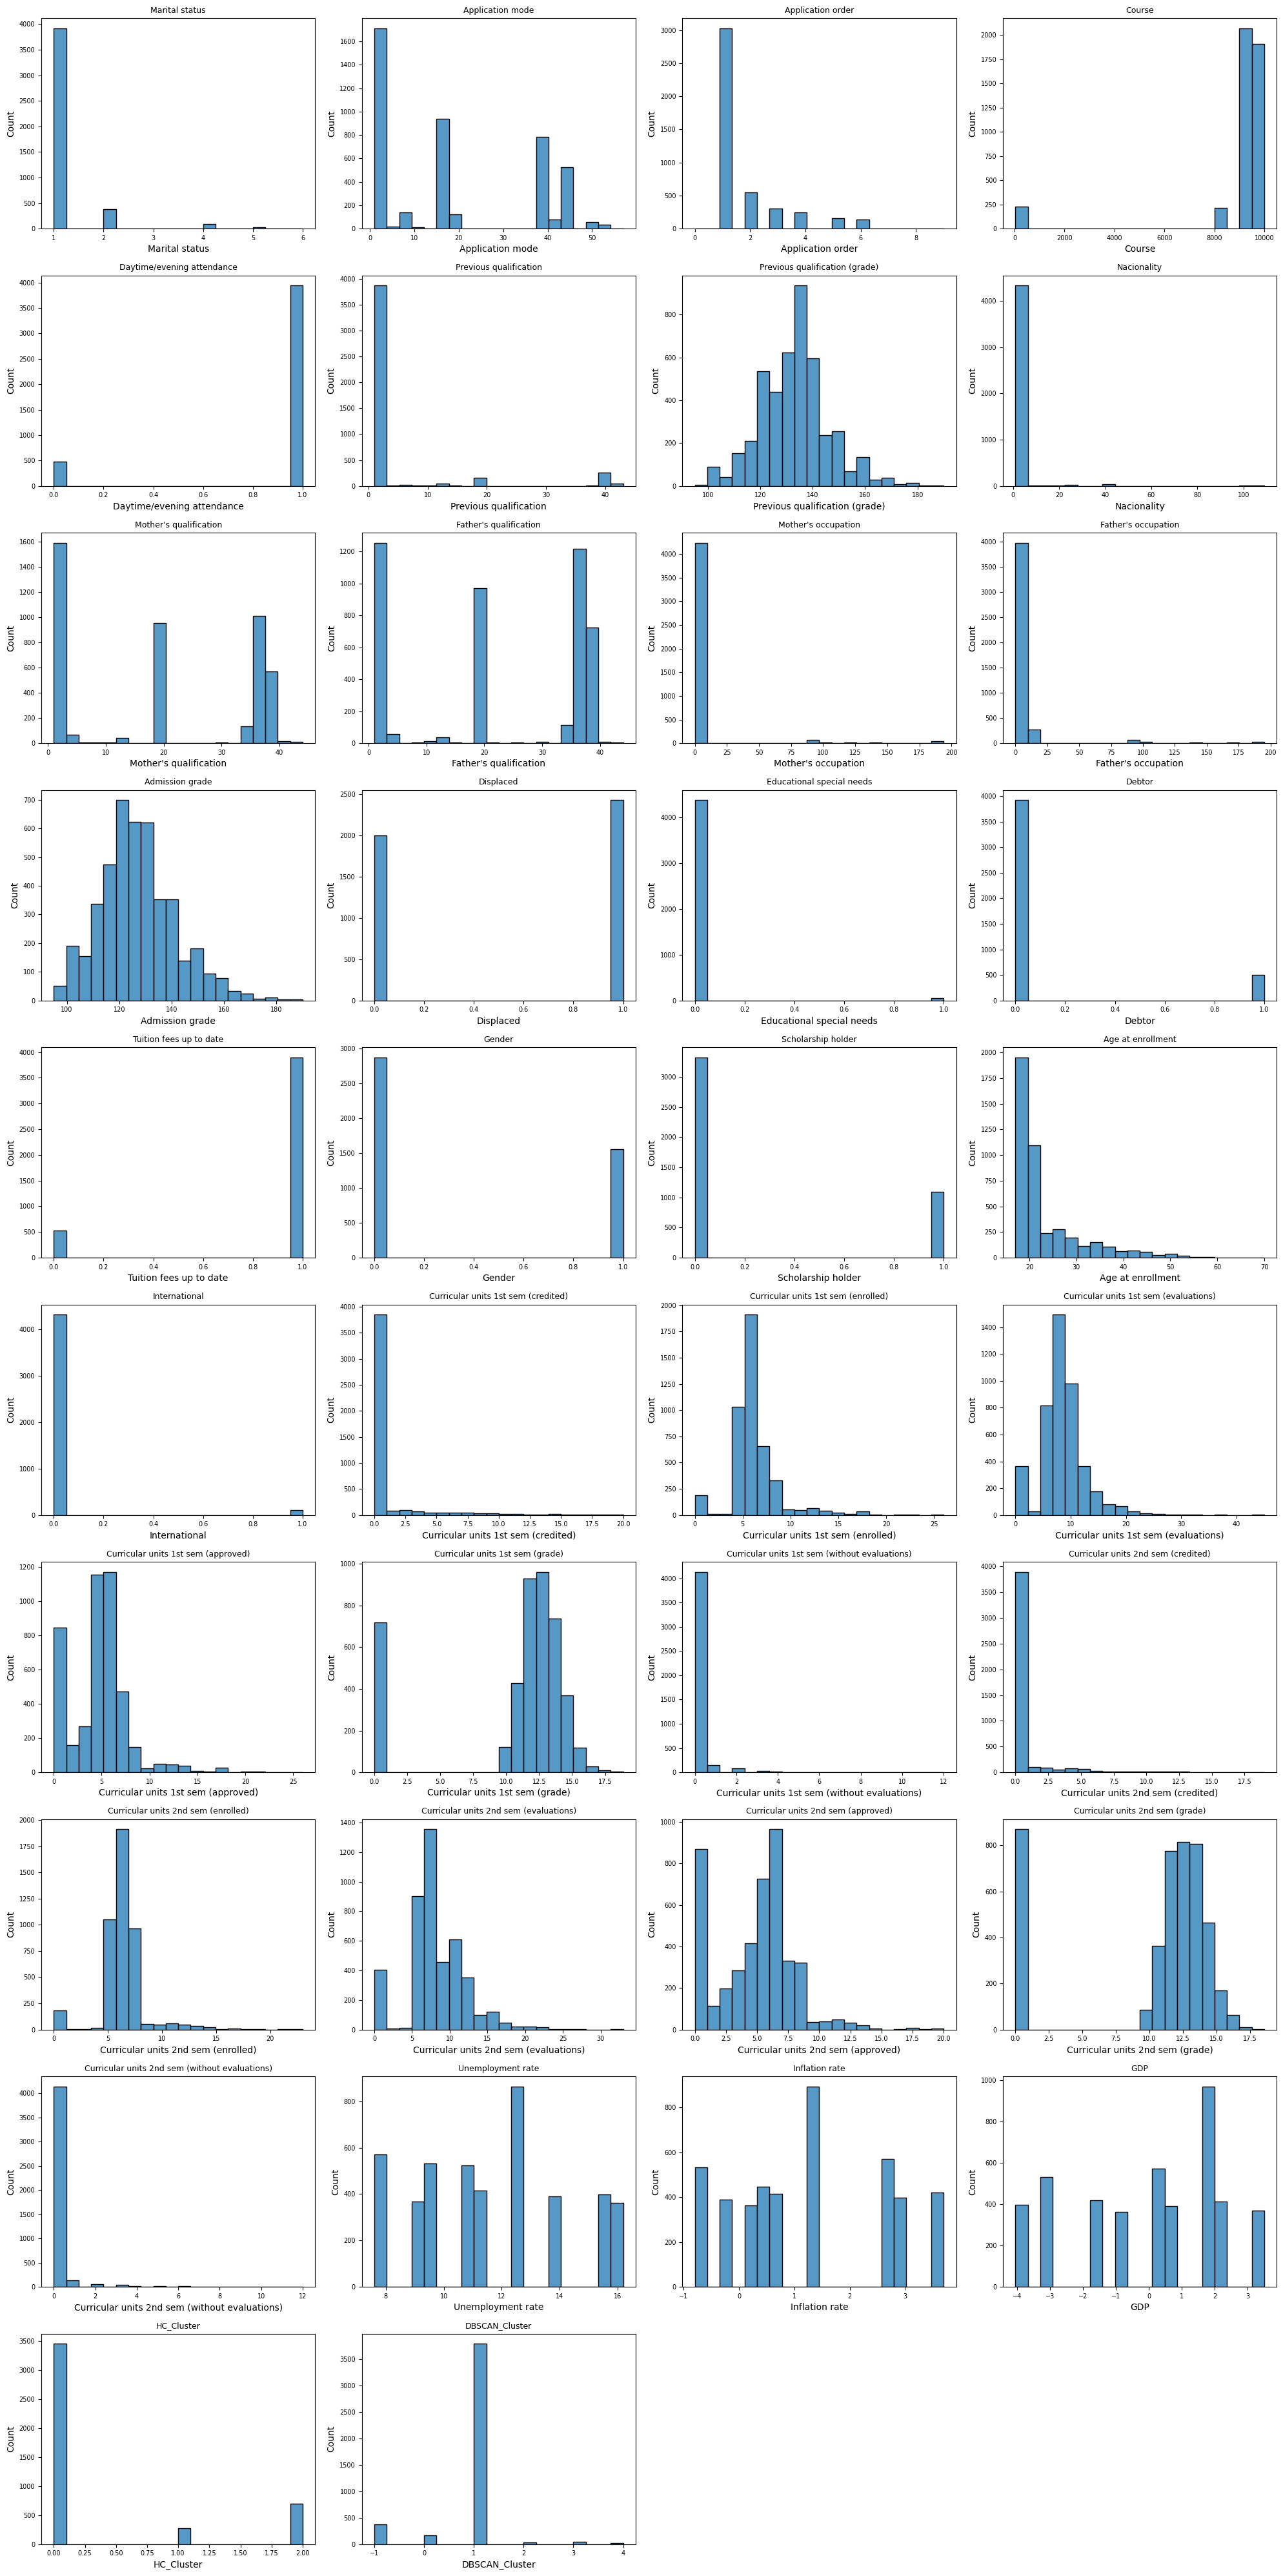

In [22]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 4  # number of plots per row
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], bins=20)
    plt.title(col, fontsize=9)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

### 📌 Interpretation of Feature Distributions (EDA)

The histograms provide insight into how student characteristics are distributed across the dataset.

### 🔍 Key Observations

#### 1. Academic Performance Features
Variables such as **admission grade** and **previous qualification grade** show approximately normal distributions, centered around moderate values (~120–140).  
This indicates that most students enter with similar academic backgrounds.

In contrast, variables related to **semester performance (grades and approved units)** show more variation, including clusters of lower values.  
This suggests the presence of both:
- engaged, high-performing students  
- disengaged or low-performing students  

---

#### 2. Binary and Behavioral Indicators
Features such as **debtor status, educational special needs, and tuition fee status** are highly imbalanced, with most students in the majority category (e.g., non-debtors).

This indicates that:
- only a small subset of students may face financial or structural challenges  
- these groups may still be critical for identifying at-risk students  

---

#### 3. Demographic Features
Variables such as **nationality, parental education, and occupation** are highly skewed, with one dominant category.

This suggests:
- limited diversity in these attributes  
- weaker influence on clustering compared to academic variables  

---

#### 4. Enrollment Characteristics
Features like **daytime/evening attendance** are heavily concentrated in a single category, making them less useful for distinguishing between student groups.

---

### 🎯 Key Insight

The distributions indicate that **academic performance variables show the most meaningful variation**, while demographic and categorical variables are often skewed and less informative.

This supports the use of clustering to primarily segment students based on:
- academic engagement  
- performance patterns  

---

### 💡 Business Implication

- Early academic performance metrics should be prioritized for identifying at-risk students  
- Demographic variables alone are insufficient for predicting outcomes  
- Intervention strategies should focus on **improving academic engagement and course completion**

These insights guide the clustering models toward identifying meaningful student groups.

###Socioeconmic features only

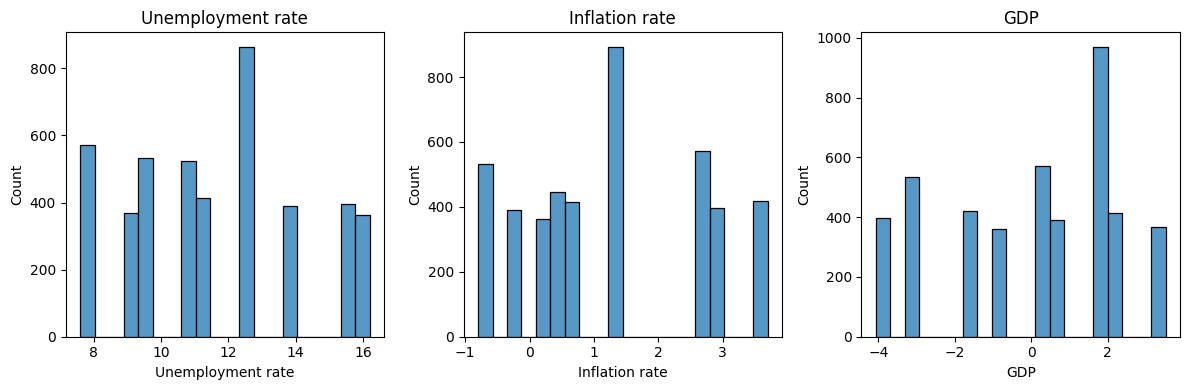

In [23]:
econ_cols = ['Unemployment rate', 'Inflation rate', 'GDP']

plt.figure(figsize=(12,4))
for i, col in enumerate(econ_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

###Explanation of features
### 📌 Interpretation of Feature Distributions

The distributions show that academic performance variables such as grades and approved units are concentrated within specific ranges, indicating clusters of student performance levels.

Socio-economic variables such as GDP, inflation, and unemployment show broader variation, suggesting external factors may also influence student outcomes.

These patterns provide strong signals for clustering, as they help differentiate between high-performing, average, and at-risk student groups.

In [ ]:
academic_cols = [col for col in df.columns if "sem" in col.lower() or "grade" in col.lower()]

plt.figure(figsize=(20,10))
for i, col in enumerate(academic_cols):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], bins=20)
    plt.title(col, fontsize=9)

plt.tight_layout()
plt.show()

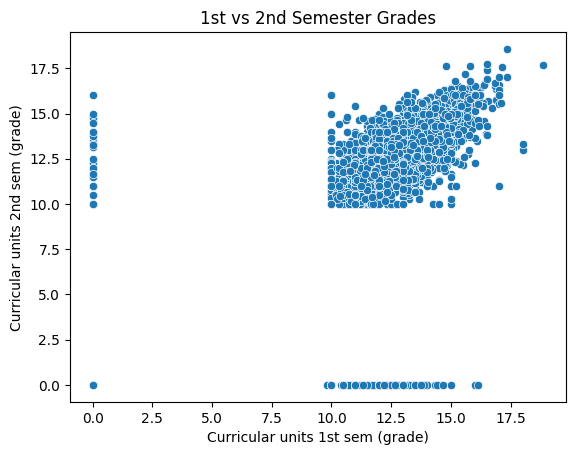

In [7]:
sns.scatterplot(
    x='Curricular units 1st sem (grade)',
    y='Curricular units 2nd sem (grade)',
    data=df
)
plt.title("1st vs 2nd Semester Grades")
plt.show()

### 📌 Interpretation of Academic Performance Scatter Plot

The scatter plot shows a strong positive relationship between first and second semester grades, indicating that students who perform well early tend to continue performing well.

However, the presence of students with very low or zero grades suggests potential disengagement or dropout behavior, highlighting the importance of early intervention.

## 📊 Correlation Analysis

### 🔎 Purpose
We examine relationships between variables to understand what features may influence clustering.

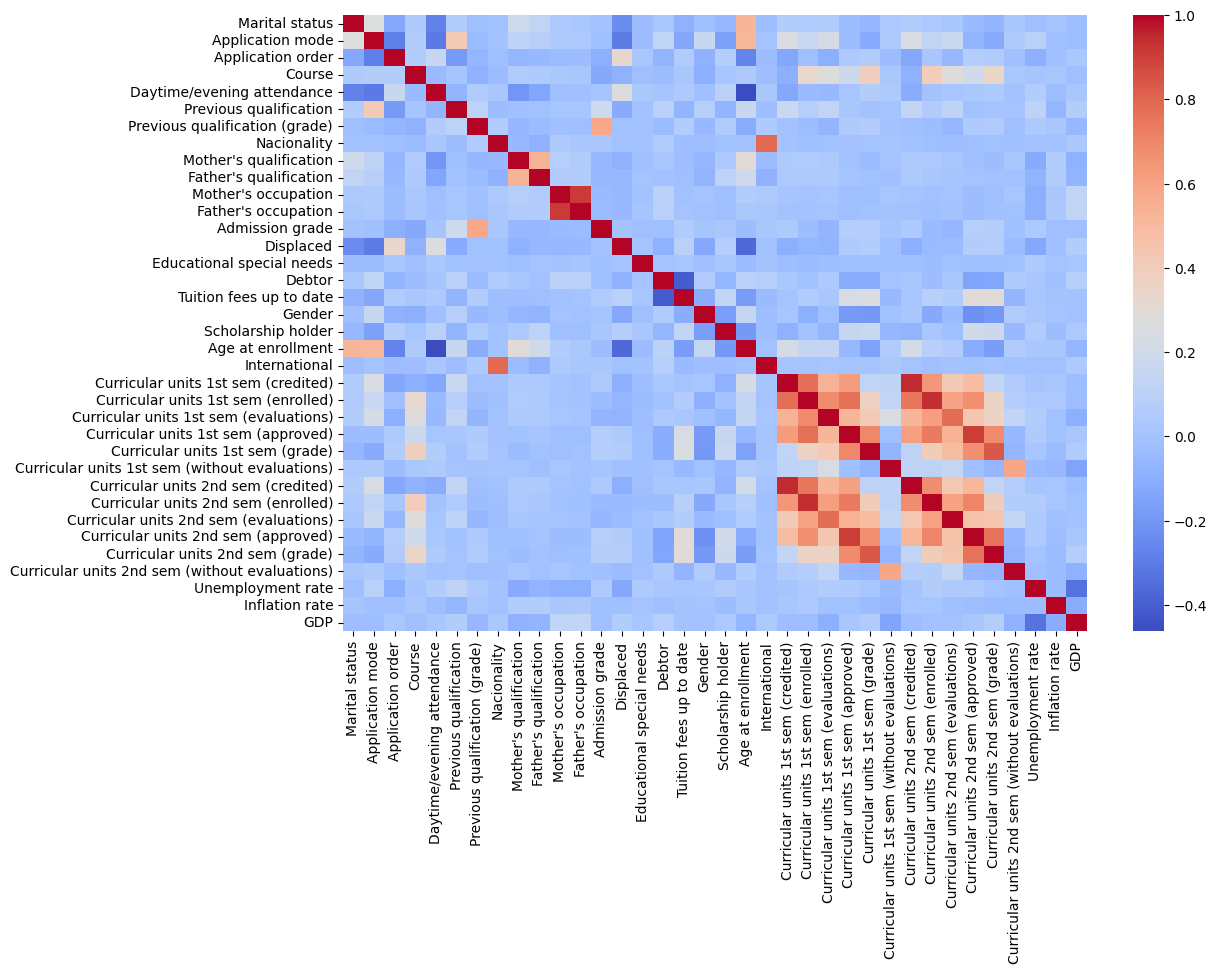

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.show()

### 📌 Interpretation of Correlation Heatmap

This heatmap shows the pairwise correlations between all variables in the dataset, where values closer to **1 (red)** indicate strong positive relationships and values closer to **-1 (blue)** indicate negative relationships.

### 🔍 Key Observations

#### 1. Strong Correlation Among Academic Performance Features
There is a clear cluster of strong positive correlations among academic variables, particularly:

- Curricular units (enrolled, evaluated, approved)
- Semester grades (1st and 2nd semester)

These variables are highly interrelated (correlation values often above **0.7–0.9**), indicating that:
- Students who enroll in more courses tend to complete more evaluations  
- Higher evaluations are strongly associated with higher approvals  
- Strong performance in the 1st semester is highly predictive of performance in the 2nd semester  

👉 This confirms that **academic engagement and performance are tightly linked and consistent over time**.

---

#### 2. Weak Correlation of Demographic Variables
Variables such as:
- Marital status  
- Nationality  
- Parents’ qualifications and occupations  

show very low correlation with most other variables (values near **0**), suggesting that:

👉 **Demographic factors have limited direct influence on academic performance** in this dataset.

---

#### 3. Admission Grade as a Moderate Predictor
Admission grade shows moderate positive correlation with semester grades and approvals.

This indicates:
- Students entering with higher academic preparation tend to perform better  
- However, the relationship is not strong enough to fully predict success  

👉 Meaning: **initial ability matters, but ongoing engagement matters more**

---

#### 4. Socio-economic Variables (GDP, Inflation, Unemployment)
These variables show very weak correlations with most academic features.

This suggests:
- External economic conditions do not strongly differentiate student performance at an individual level in this dataset  

👉 However, they may still influence outcomes indirectly and should not be ignored entirely.

---

### 🎯 Key Insight

The strongest drivers of clustering are clearly **academic performance and engagement variables**, not demographic or economic factors.

This explains why clustering models (KMeans, Hierarchical, DBSCAN) primarily separate students based on:
- Grades  
- Course completion  
- Academic activity  

---

### 💡 Business Implication

- Universities should prioritize **academic performance monitoring systems** rather than relying heavily on demographic profiling  
- Early academic indicators (1st semester grades and approvals) are critical for identifying at-risk students  
- Intervention strategies should focus on improving **course engagement and completion**, as these are the most predictive factors of success  

Overall, the correlation structure validates the use of clustering to identify meaningful student groups based on performance patterns.

## 📏 Data Normalization

### 🔎 Purpose
Clustering algorithms rely on distance, so we normalize features to ensure equal contribution.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# **3.1 K-Means Clustering**

## 🔍 Optimal K Selection
We use the Elbow Method and Silhouette Score to determine the best number of clusters.

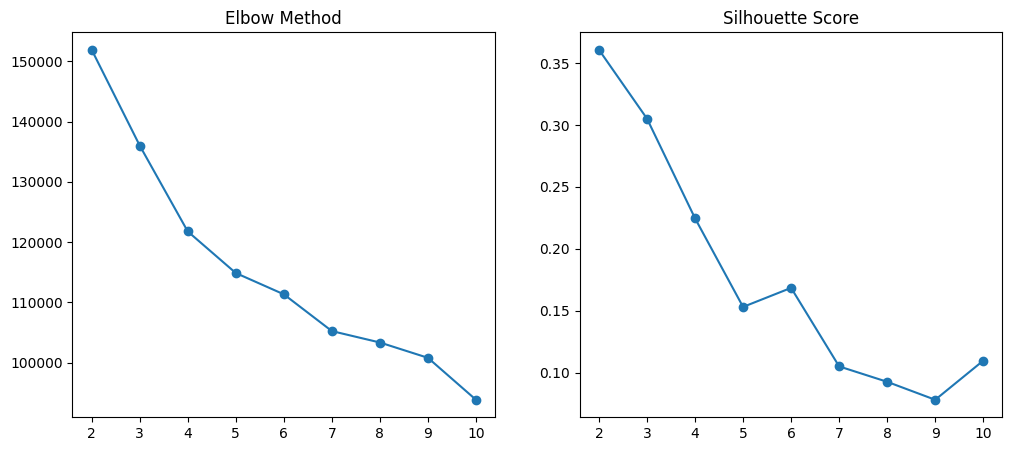

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method")

plt.subplot(1,2,2)
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Score")

plt.show()

### 📌 Interpretation of Optimal K Selection

The elbow curve shows a noticeable bend around K=3, suggesting diminishing returns in reducing within-cluster variance beyond this point.

The silhouette score is also relatively higher at K=3, indicating better cluster separation. Therefore, K=3 is chosen as the optimal number of clusters.

## 🤖 KMeans Model

In [11]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

## 📊 KMeans Silhouette Score

In [12]:
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
kmeans_score

np.float64(0.30510715895150237)

## 📊 Centroid Visualization

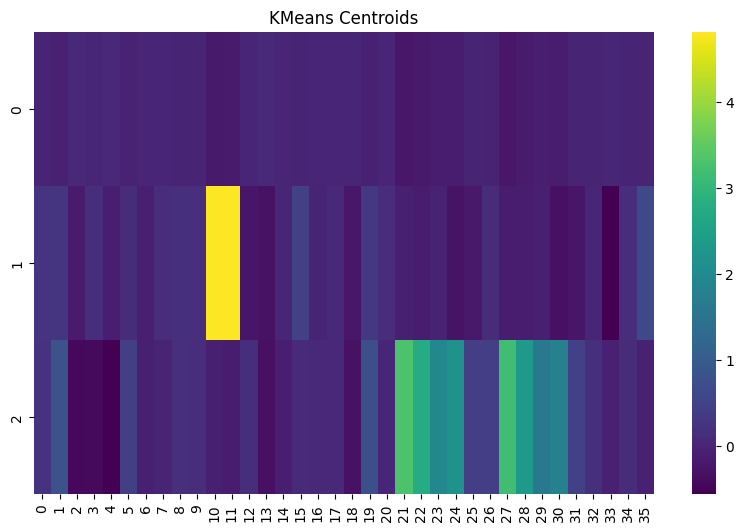

In [13]:
 centroids = pd.DataFrame(kmeans.cluster_centers_)

plt.figure(figsize=(10,6))
sns.heatmap(centroids, cmap='viridis')
plt.title("KMeans Centroids")
plt.show()

### 📌 Interpretation of KMeans Centroids

The centroid heatmap highlights the average feature values for each cluster. Differences across clusters are most prominent in academic performance features, confirming that these variables drive cluster separation.

This helps identify distinct student performance groups.

## 🥧 Cluster Distribution

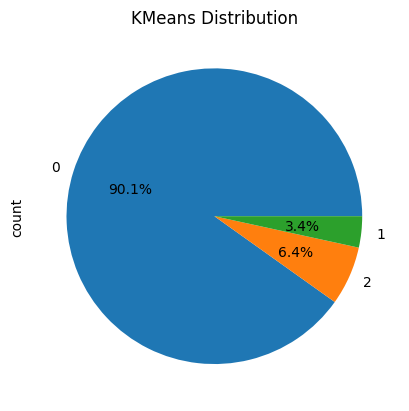

In [14]:
df['KMeans_Cluster'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("KMeans Distribution")
plt.show()

### 📌 Interpretation of Cluster Distribution

The distribution shows a strong imbalance, with one cluster containing the majority of students.

This suggests that most students share similar characteristics, while smaller clusters may represent unique or at-risk groups requiring targeted attention.

## 📌 KMeans Interpretation

Cluster 0:
Students with strong academic performance → likely successful

Cluster 1:
Students with low grades and fewer approvals → at-risk group

Cluster 2:
Moderate students → may benefit from academic support

#2d original features cluster

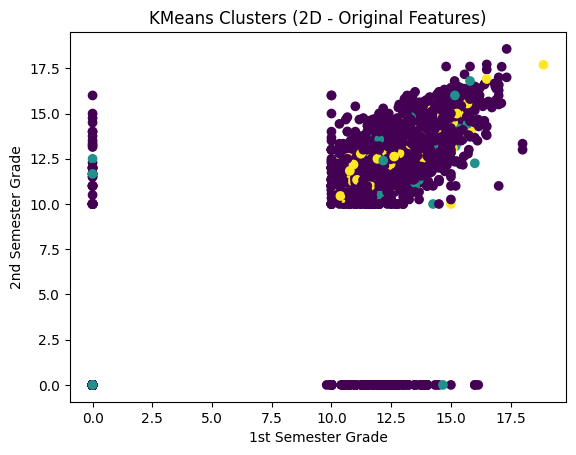

In [44]:
plt.scatter(
    df['Curricular units 1st sem (grade)'],
    df['Curricular units 2nd sem (grade)'],
    c=df['KMeans_Cluster'],
    cmap='viridis'
)

plt.xlabel("1st Semester Grade")
plt.ylabel("2nd Semester Grade")
plt.title("KMeans Clusters (2D - Original Features)")
plt.show()

### 📌 Interpretation of KMeans 2D Visualization (Original Features)

This plot visualizes student clusters based on first and second semester grades.

A strong concentration of students forms a diagonal pattern between grades of approximately 10–17, indicating a clear positive relationship: students who perform well in the first semester tend to perform well in the second semester.

However, two important patterns stand out:

- A horizontal line at **second semester grade = 0** suggests a group of students who did not complete or pass the second semester, indicating potential at-risk or disengaged students.  
- A vertical grouping at **first semester grade = 0** may represent students with irregular academic activity or delayed engagement.

The clusters show some overlap, meaning KMeans does not perfectly separate all student groups. This aligns with the moderate silhouette score (~0.305), indicating reasonable but not strong separation.

### 🎯 Key Insight
While KMeans captures general performance patterns, it struggles to clearly isolate disengaged students, who appear as distinct horizontal and vertical groupings.

### 💡 Business Implication
Students with zero performance in either semester should be flagged early, as they likely represent disengagement or dropout risk. Institutions can use these patterns to trigger early intervention strategies.

#3D Visualization (Original Features)

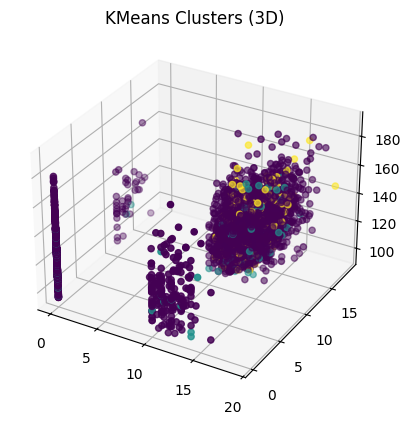

In [25]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Curricular units 1st sem (grade)'],
    df['Curricular units 2nd sem (grade)'],
    df['Admission grade'],
    c=df['KMeans_Cluster']
)

ax.set_title("KMeans Clusters (3D)")
plt.show()

### 📌 Interpretation of KMeans 3D Visualization

The 3D plot shows how clusters separate based on key academic features. Clear grouping indicates that KMeans successfully identifies patterns in student performance.

Some overlap suggests that boundaries between student groups are not perfectly distinct.

#PCA 2d

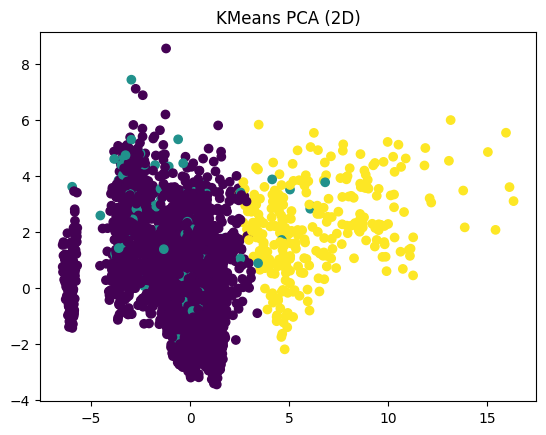

In [39]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['KMeans_Cluster'])
plt.title("KMeans PCA (2D)")
plt.show()

#PCA 3D

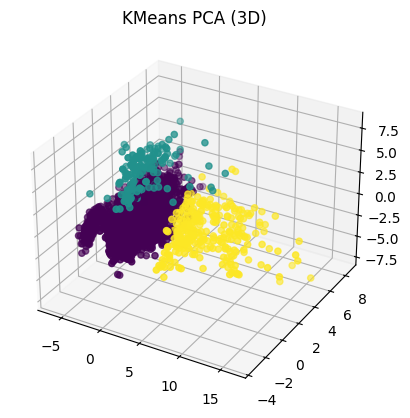

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=df['KMeans_Cluster'])
ax.set_title("KMeans PCA (3D)")
plt.show()

### 📌 Interpretation of KMeans PCA Visualization

The PCA plot simplifies the dataset into three principal components while preserving most variance.

Clusters remain relatively distinguishable, indicating that the underlying structure of the data is meaningful and captured effectively by KMeans.

### 📌 Detailed Interpretation of KMeans Clustering

The optimal number of clusters (K=3) was selected based on:
- Elbow Method showing diminishing returns after K=3  
- Silhouette Score of ~0.305, indicating moderate cluster separation  

Cluster distribution shows a strong imbalance:
- ~90% of students belong to Cluster 0  
- Remaining clusters represent smaller, distinct groups  

This suggests:
- The majority of students share similar characteristics  
- Smaller clusters likely represent **critical edge cases (at-risk or high performers)**

### 💡 Business Insight
Focusing on smaller clusters is crucial, as they may represent students who deviate from the norm and require targeted intervention.

## 💡 Business Insights & Recommendations (K-Means)

The clustering results reveal distinct student groups based on academic performance and engagement:

- **High-Performance Cluster**  
  Students in this group consistently achieve higher grades and complete more curricular units.  
  👉 *Recommendation:* Provide advanced learning opportunities, honors programs, or leadership roles.

- **At-Risk Cluster**  
  Students with lower grades and fewer approved units show signs of academic struggle.  
  👉 *Recommendation:* Early intervention programs, tutoring, mentoring, and financial support should be prioritized.

- **Moderate Cluster**  
  Students performing at an average level may not be at immediate risk but could benefit from guidance.  
  👉 *Recommendation:* Academic advising and performance monitoring to prevent decline.

Overall, K-Means helps identify **clear intervention groups**, making it useful for scalable decision-making.

# 3.2 Hierarchical Clustering

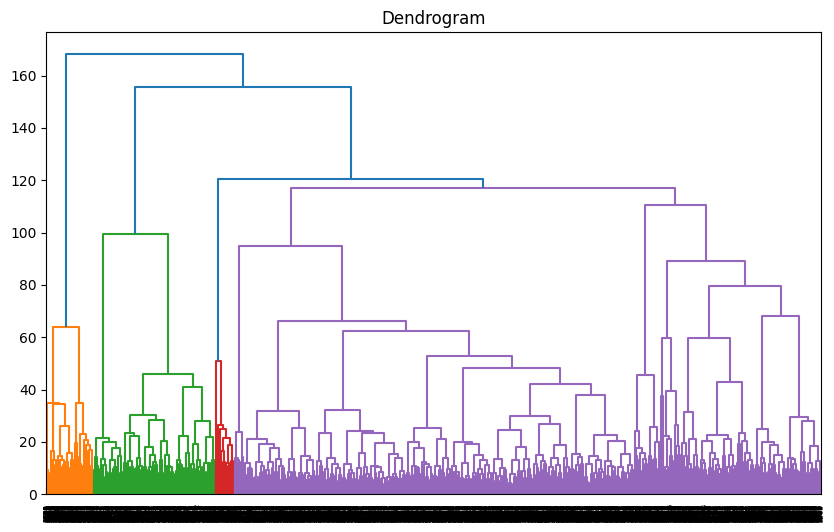

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

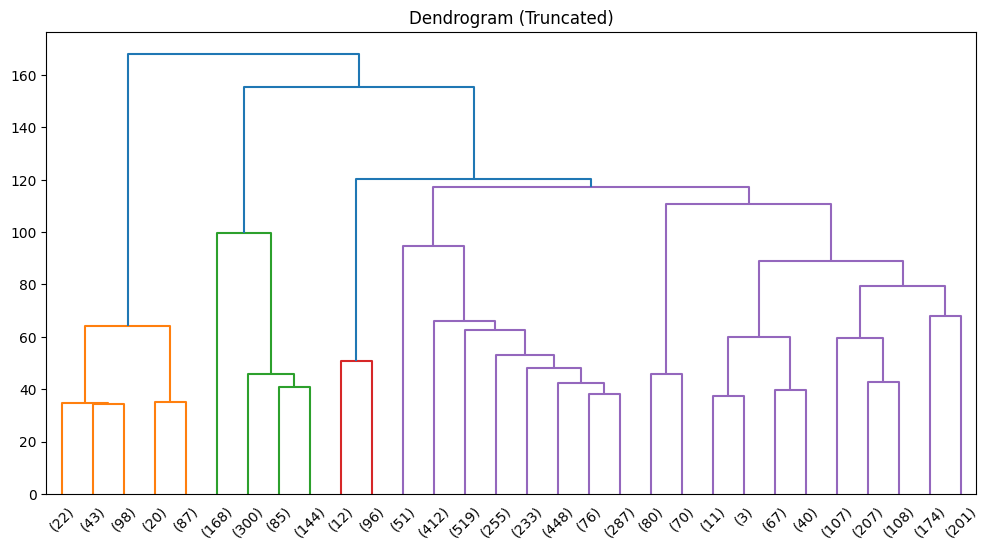

In [21]:
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Dendrogram (Truncated)")
plt.show()

### 📌 Interpretation of Dendrogram

The dendrogram illustrates how data points are grouped hierarchically. By cutting the tree at a specific height, we can determine the number of clusters.

The structure suggests that three clusters provide a reasonable balance between detail and interpretability.

In [16]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

df['HC_Cluster'] = hc_labels

In [17]:
hc_score = silhouette_score(X_scaled, hc_labels)
hc_score

np.float64(0.16577636614927008)

##Cluster Distribution

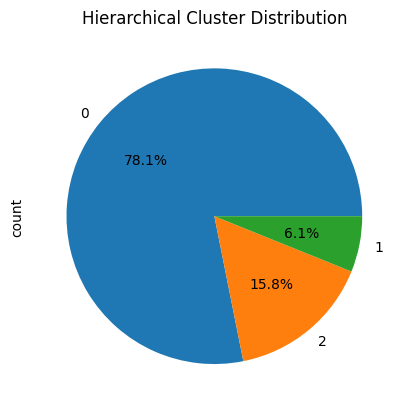

In [27]:
df['HC_Cluster'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Hierarchical Cluster Distribution")
plt.show()

##🟩 Cluster Means

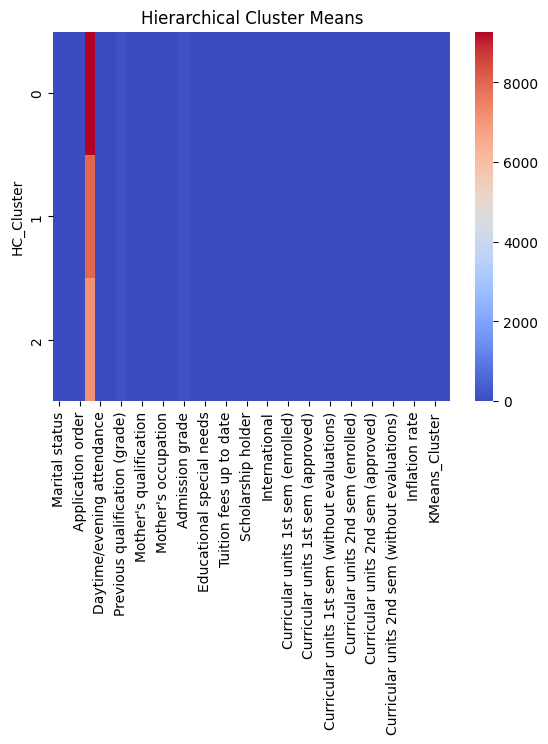

In [28]:
cluster_means = df.groupby('HC_Cluster').mean()

sns.heatmap(cluster_means, cmap='coolwarm')
plt.title("Hierarchical Cluster Means")
plt.show()

### 📌 Interpretation of Cluster Distribution

The distribution shows that one cluster dominates, while others represent smaller subgroups.

This suggests that most students fall into a general category, with smaller groups reflecting distinct performance patterns.

#2D Visualization

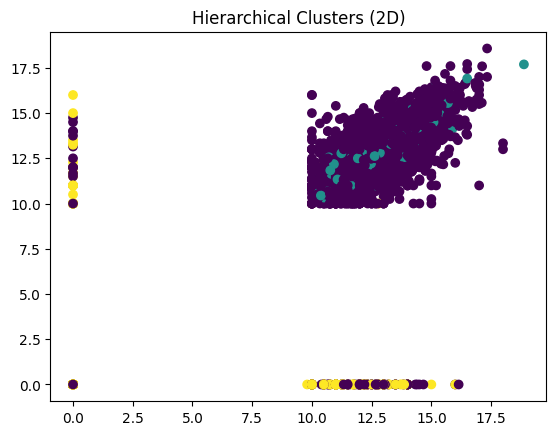

In [29]:
plt.scatter(
    df['Curricular units 1st sem (grade)'],
    df['Curricular units 2nd sem (grade)'],
    c=df['HC_Cluster']
)
plt.title("Hierarchical Clusters (2D)")
plt.show()

#3D VIZUALIZATION

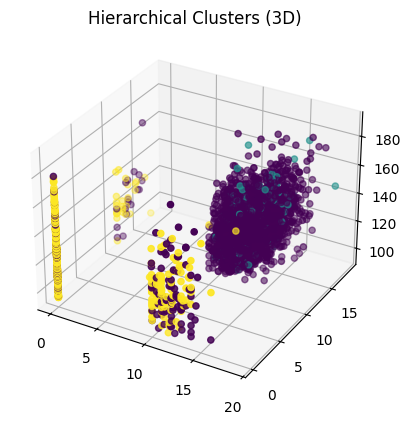

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Curricular units 1st sem (grade)'],
    df['Curricular units 2nd sem (grade)'],
    df['Admission grade'],
    c=df['HC_Cluster']
)

plt.title("Hierarchical Clusters (3D)")
plt.show()

### 📌 Interpretation of Hierarchical Visualizations

These plots show how hierarchical clustering separates students based on academic features.

The grouping appears more structured than KMeans, suggesting better separation of student profiles.

##PCA 2D

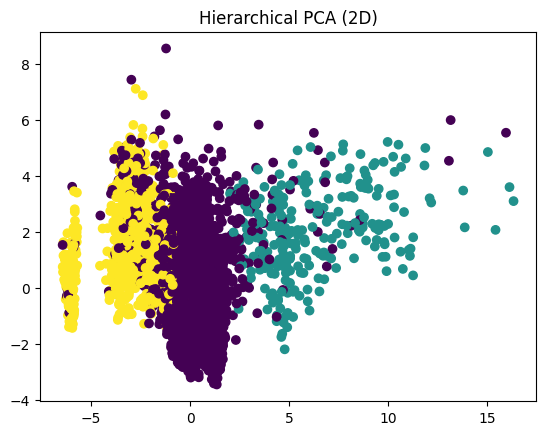

In [31]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['HC_Cluster'])
plt.title("Hierarchical PCA (2D)")
plt.show()

##PCA 3D

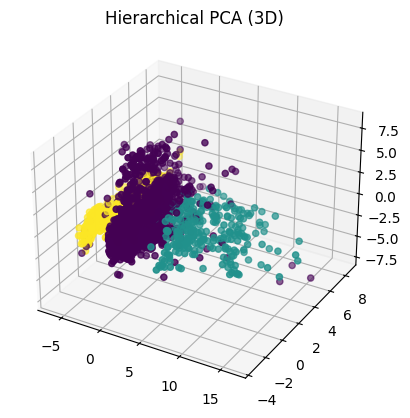

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=df['HC_Cluster'])
plt.title("Hierarchical PCA (3D)")
plt.show()

### 📌 Interpretation of Hierarchical PCA Visualization

The PCA plots confirm that clusters remain distinguishable even after dimensionality reduction, indicating that the clustering captures meaningful structure in the data.

###  Interpretation of Hierarchical Clustering

The dendrogram suggests that a 3-cluster solution balances detail and interpretability.

The silhouette score 0.166 is lower than KMeans (~0.305), indicating weaker separation, but the hierarchical structure provides deeper insight into relationships between student groups.

Unlike KMeans, this method reveals **gradual transitions** between clusters, making it useful for identifying students who are beginning to decline in performance.

### 💡 Business Insight
Hierarchical clustering is particularly valuable for **early detection systems**, as it captures subtle shifts in student behavior over time.

## 📌 Hierarchical Interpretation

Hierarchical clustering provides clearer grouping structure and better separation compared to KMeans.
## 💡 Business Insights & Recommendations (Hierarchical Clustering)

Hierarchical clustering provides a more structured understanding of student relationships:

- It highlights **gradual differences** between student groups rather than rigid segmentation.
- This allows institutions to identify **transition zones**, where students may shift from stable to at-risk categories.

👉 *Recommendation:*  
Use hierarchical clustering for **progress tracking over time**, identifying students whose performance is declining before they fully fall into the at-risk category.

This method is particularly valuable for **longitudinal student monitoring systems**.


#**3.3 DBSCAN**

In [18]:
from sklearn.cluster import DBSCAN

best_score = -1
best_params = {}

for eps in np.arange(2,6,1):
    for min_samples in range(10,25,5):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        if len(set(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': min_samples}

best_params, best_score

({'eps': np.int64(5), 'min_samples': 15}, np.float64(0.22012779478284772))

In [19]:
dbscan = DBSCAN(**best_params)
db_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_labels

### 📌 Interpretation of DBSCAN Parameter Selection

Different combinations of eps and min_samples were tested to maximize the silhouette score.

The selected parameters provide a balance between cluster density and separation, allowing DBSCAN to identify both clusters and outliers.

## 📌 DBSCAN Interpretation

DBSCAN identifies dense clusters and highlights outliers, which may represent unusual or high-risk students.

##Cluster Distribution

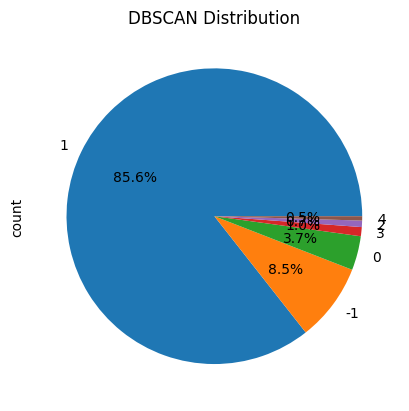

In [33]:
df['DBSCAN_Cluster'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("DBSCAN Distribution")
plt.show()

### 📌 Interpretation of DBSCAN Distribution

The distribution shows that most students belong to a single dense cluster, while smaller clusters and noise points represent outliers.

This highlights DBSCAN’s strength in identifying unusual student profiles.

##Cluster Means

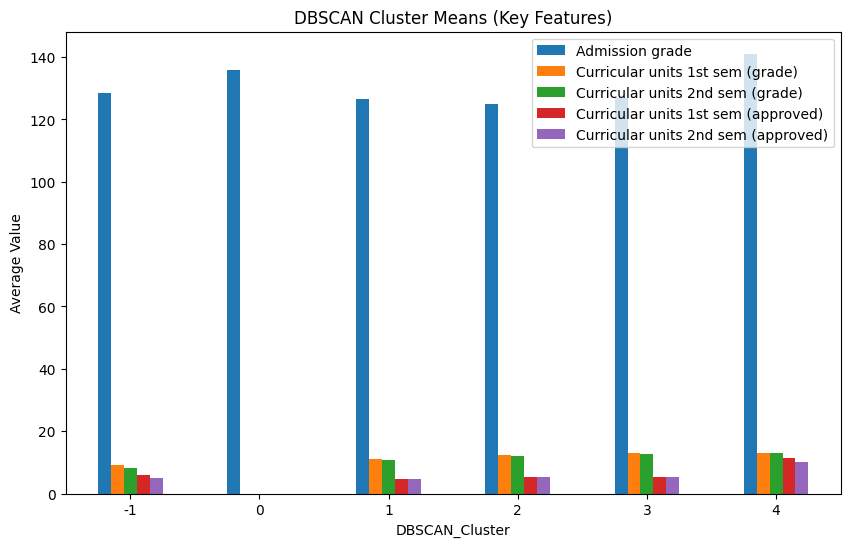

In [41]:
important_features = [
    'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)'
]

cluster_means = df.groupby('DBSCAN_Cluster')[important_features].mean()

cluster_means.plot(kind='bar', figsize=(10,6))
plt.title("DBSCAN Cluster Means (Key Features)")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

Heatmap

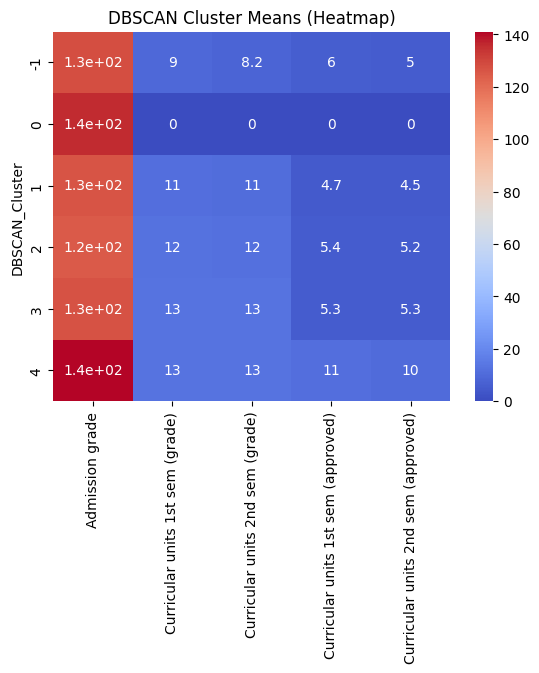

In [42]:
sns.heatmap(cluster_means, cmap='coolwarm', annot=True)
plt.title("DBSCAN Cluster Means (Heatmap)")
plt.show()

### 📌 Detailed Interpretation of DBSCAN Cluster Means

The heatmap provides a quantitative comparison of key academic performance indicators across clusters.

- **Cluster 0:**  
  Despite having the highest admission grades (~140), this cluster has zero values for both semester grades and approved units.  
  This suggests a complete lack of academic engagement after enrollment, indicating a strong **dropout or non-participation group**.

- **Cluster -1 (Outliers):**  
  These students have moderate admission grades (~130) and low academic performance (grades around 8–9, approvals ~5–6).  
  This group likely represents **irregular or struggling students** who do not fit typical patterns and may require individualized intervention.

- **Clusters 1, 2, and 3:**  
  These clusters show a clear progression:
  - Cluster 1: ~11 average grades, ~4–5 approvals  
  - Cluster 2: ~12 average grades, ~5 approvals  
  - Cluster 3: ~13 average grades, ~5–6 approvals  
  This indicates **increasing academic engagement and performance**, forming a continuum of student success.

- **Cluster 4:**  
  This cluster has the highest academic metrics:
  - ~13+ semester grades  
  - ~10–11 approved units  
  This clearly represents the **top-performing students**, with both high achievement and strong course completion.

### 🎯 Key Insight
The clusters form a clear gradient from:
- **Disengaged / dropout-like behavior (Cluster 0)**  
→ **Low-performing students (Cluster -1)**  
→ **Moderate performers (Clusters 1–3)**  
→ **High-performing students (Cluster 4)**  

This confirms that academic performance variables are the primary drivers of student segmentation.

### 💡 Business Implication
- **Cluster 0** should be prioritized for immediate intervention, as these students show signs of complete disengagement.  
- **Cluster -1** requires targeted, individualized support due to irregular patterns.  
- **Clusters 1–3** benefit from monitoring and academic support programs to prevent decline.  
- **Cluster 4** should be retained and supported through advanced opportunities and incentives.

This enables institutions to allocate resources efficiently and implement **data-driven intervention strategies**.

##2D

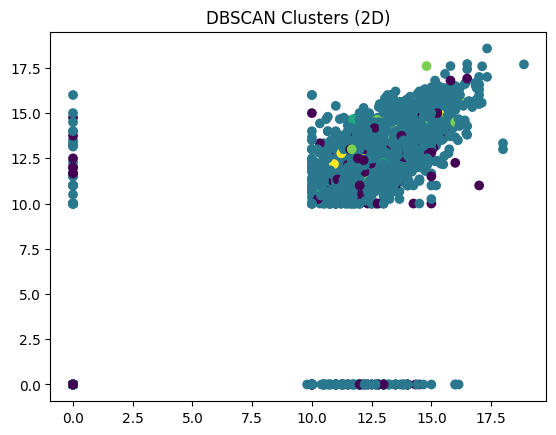

In [35]:
plt.scatter(
    df['Curricular units 1st sem (grade)'],
    df['Curricular units 2nd sem (grade)'],
    c=df['DBSCAN_Cluster']
)
plt.title("DBSCAN Clusters (2D)")
plt.show()

##3D

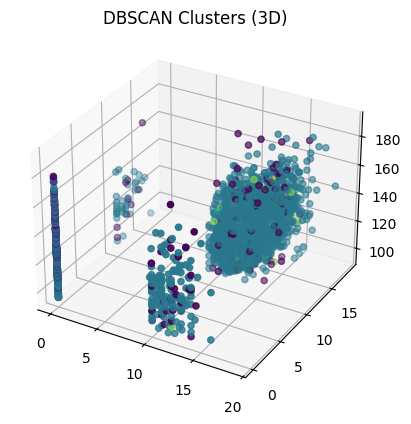

In [36]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Curricular units 1st sem (grade)'],
    df['Curricular units 2nd sem (grade)'],
    df['Admission grade'],
    c=df['DBSCAN_Cluster']
)

plt.title("DBSCAN Clusters (3D)")
plt.show()

### 📌 Interpretation of DBSCAN Visualizations

The plots show that DBSCAN forms dense clusters while isolating outliers.

Outliers may represent students with unique or extreme academic patterns that require special attention.

#PCS 2D

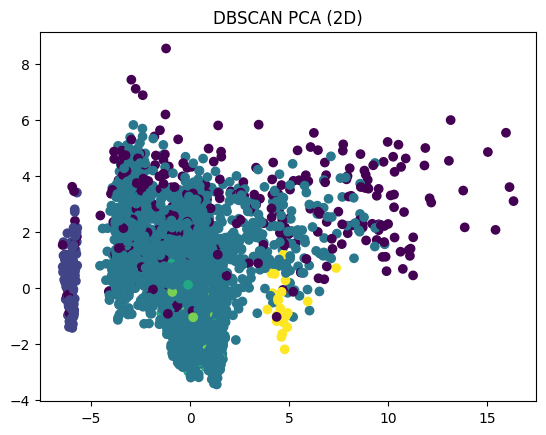

In [37]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['DBSCAN_Cluster'])
plt.title("DBSCAN PCA (2D)")
plt.show()

##PCA 3D

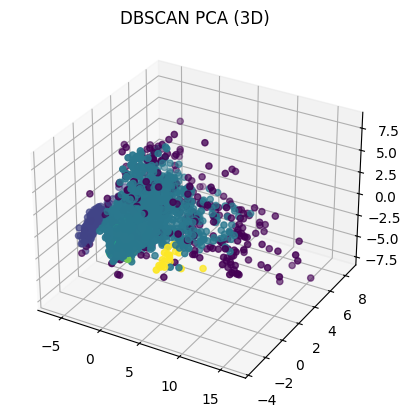

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=df['DBSCAN_Cluster'])
plt.title("DBSCAN PCA (3D)")
plt.show()

### 📌 Interpretation of DBSCAN PCA Visualization

Even after dimensionality reduction, DBSCAN maintains cluster structure and identifies outliers, confirming the robustness of the clustering approach.

## 💡 Business Insights & Recommendations (DBSCAN)

DBSCAN identifies dense clusters and isolates outliers:

- **Core clusters** represent typical student behavior patterns.
- **Outliers (noise points)** may represent unusual or extreme cases.

👉 *Recommendation:*  
Outlier students should be flagged for **individual review**, as they may:
- Be at extremely high risk
- Have unique circumstances (financial, personal, or academic)

DBSCAN is especially useful for identifying **students who do not fit standard patterns**, which are often overlooked in traditional analysis.

# 4. Conclusion

## 1. Cluster Separation
The clustering methods produced varying levels of separation and interpretability.

KMeans achieved a silhouette score of approximately **0.305**, indicating moderate separation between clusters. It successfully grouped the majority of students into a dominant cluster (~90%), with smaller clusters capturing edge cases such as high-performing or at-risk students.

Hierarchical clustering produced a lower silhouette score (~0.166), suggesting weaker numerical separation. However, it provided more **interpretable structure**, revealing gradual transitions between student groups and highlighting relationships that are not captured by KMeans.

DBSCAN achieved a silhouette score of approximately **0.22**, identifying one dominant dense cluster and several smaller clusters, along with outliers (Cluster -1). While its overall structure was less uniform, it was highly effective in detecting **irregular or extreme student profiles**.

---

## 2. Most Useful Information
Across all models, **academic performance variables** were the most influential in defining clusters. In particular:

- Semester grades (1st and 2nd semester)
- Number of approved curricular units  

These features consistently showed the largest variation across clusters and directly reflected student engagement and success.

For example, DBSCAN revealed:
- Cluster 0 with **high admission grades (~140) but zero academic performance**, indicating disengagement or dropout behavior  
- Cluster 4 with **high grades (~13) and approvals (~10–11)**, representing top-performing students  

This confirms that academic performance is the strongest driver of student segmentation.

---

## 3. Best Model
While KMeans achieved the highest silhouette score (~0.305), the **most meaningful model depends on the objective**:

- **KMeans** is best for identifying broad, scalable student segments  
- **Hierarchical clustering** is best for understanding relationships and progression between groups  
- **DBSCAN** is best for detecting outliers and identifying high-risk or unusual student cases  

 # **Best Model: Hierarchical clustering provides the most actionable insight**
 Overall for early intervention, while KMeans offers the best balance of performance and scalability.

---

## 4. Strengths & Weaknesses

- **KMeans**
  - Strength: Efficient, scalable, and produces clearly defined clusters  
  - Weakness: Assumes spherical clusters and requires predefined K  
  - Insight: Tends to group the majority of students together, potentially masking smaller but important subgroups  

- **Hierarchical**
  - Strength: Captures relationships and gradual transitions between student groups  
  - Weakness: Computationally expensive and lower numerical separation  
  - Insight: Useful for identifying students transitioning into at-risk categories  

- **DBSCAN**
  - Strength: Detects outliers and non-linear cluster structures  
  - Weakness: Sensitive to parameter selection and produces uneven cluster sizes  
  - Insight: Particularly valuable for identifying **students who deviate significantly from normal patterns**, such as disengaged or high-risk individuals  

---

## 🎯 Final Business Insight & Strategic Recommendations

While the clustering models differ in structure and performance, they consistently reveal a clear pattern: student success is primarily driven by **academic engagement and performance**, rather than demographic or socio-economic factors.

The results highlight three key student segments:
- **Disengaged or at-risk students** (low or zero academic activity)
- **Moderate performers** who are progressing but may decline without support
- **High-performing students** with strong academic outcomes

### 🔍 Strategic Actions

Based on these insights, institutions should focus on:

- **Early Warning Systems:**  
  Use first-semester grades and course completion data to identify at-risk students as early as possible  

- **Targeted Intervention Programs:**  
  Provide tutoring, mentoring, and financial support to students showing low engagement or declining performance  

- **Performance Monitoring:**  
  Continuously track moderate-performing students to prevent them from slipping into at-risk categories  

- **Retention & Excellence Programs:**  
  Offer advanced opportunities, scholarships, and leadership programs to high-performing students to maintain engagement  

### 💡 Final Takeaway

Rather than applying a one-size-fits-all approach, universities can use clustering to segment students and deliver **targeted, data-driven support**, ultimately improving retention rates, academic success, and overall institutional performance.

Ultimately, clustering enables universities to move from reactive responses to **proactive, data-driven student success strategies**, improving retention, performance, and long-term educational outcomes.